In [9]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution
jax.config.update("jax_enable_x64", True)

### Generate samples from a Gaussian mixture

In [10]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

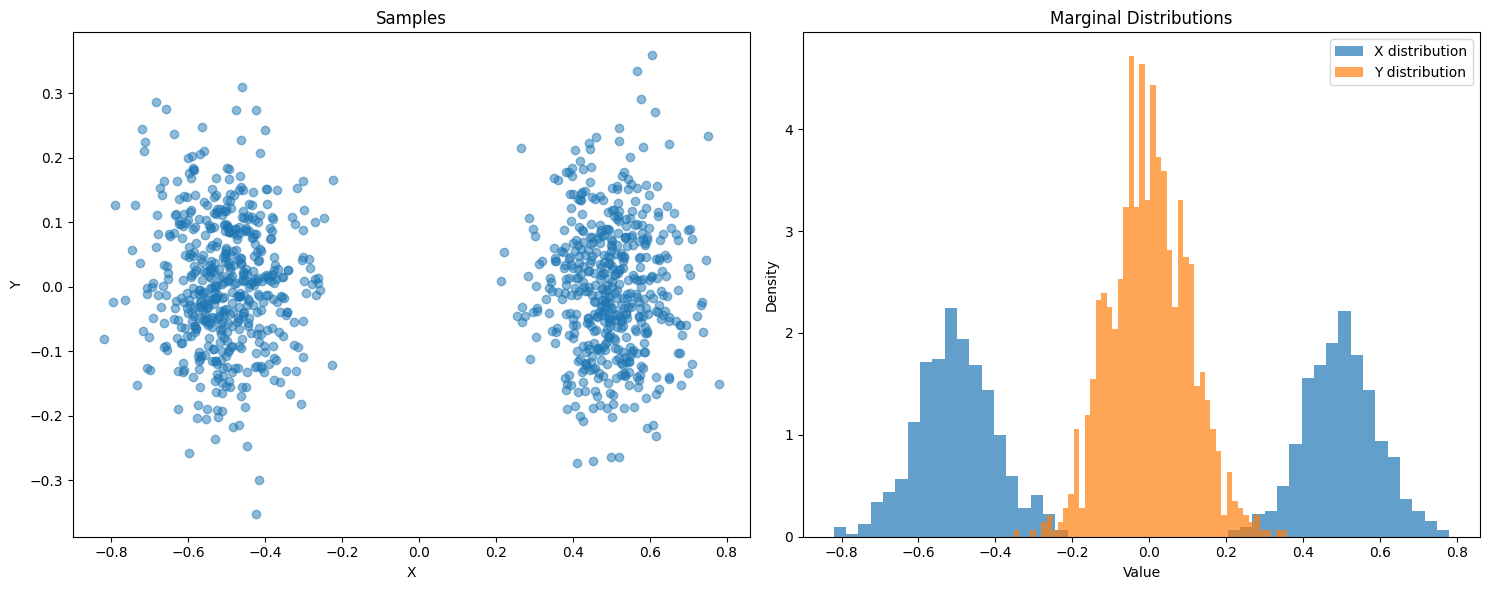

In [11]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot: Scatter plot of samples
ax1.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [12]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [13]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [14]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


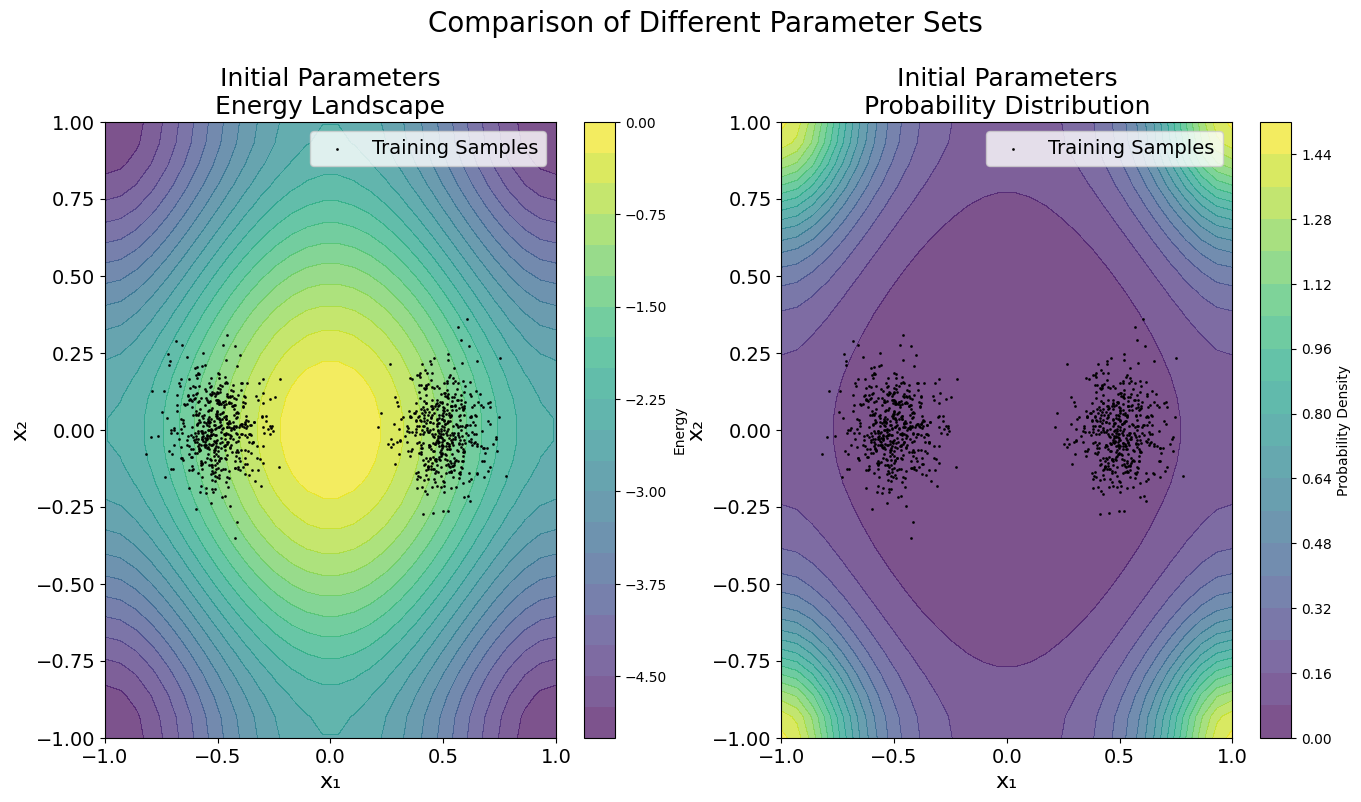

In [15]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

### Score Matching

In [ ]:
learning_rate = 0.01
n_epochs = 4000
batch_size = 128
key, subkey = jr.split(key)
loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
params_history_SM, loss_history_SM = run_optimization(loss_fn_per_batch = loss_fn_per_batch_SM, 
                                                params_initial = flattened_args_initial, 
                                                samples=samples, 
                                                gradient_fn_per_batch = None, 
                                                key=subkey,
                                                batch_size=batch_size, 
                                                learning_rate=learning_rate, 
                                                n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01 -0.01]
Loss: 18.9434
---
Epoch 100
params:
[-0.58705814 -0.01891544  1.76888339  1.96984925  0.19942903 -0.06185013]
Loss: -11.8997
---
Epoch 200
params:
[-0.60923877  0.9203035   2.47612938  2.88028597  0.13877615 -0.05377147]
Loss: -24.0452
---
Epoch 300
params:
[-0.77342121  1.81399873  3.20634241  3.7443359   0.10844964 -0.02168992]
Loss: -33.9989
---
Epoch 400
params:
[-0.95310171  2.64813048  3.96092753  4.57004784  0.10809335 -0.07195946]
Loss: -41.8443
---
Epoch 500
params:
[-1.15281096  3.42850975  4.72256127  5.33052181  0.0873113  -0.0195962 ]
Loss: -52.5888
---
Epoch 600
params:
[-1.32421609  4.14985416  5.46518923  6.03587085  0.08274926 -0.10183288]
Loss: -57.1797
---
Epoch 700
params:
[-1.55278794  4.83239454  6.1851142   6.68519892  0.05965854 -0.10527407]
Loss: -62.8920
---
Epoch 800
params:
[-1.74048862  5.4505107   6.92319251  7.26399173  0.0299737  -0.04669178]
Loss: -70.7794
---
Epoch 900
params:
[-1.94316648  6.027293

Best loss: -1.1170e+02
Found at epoch: 3040


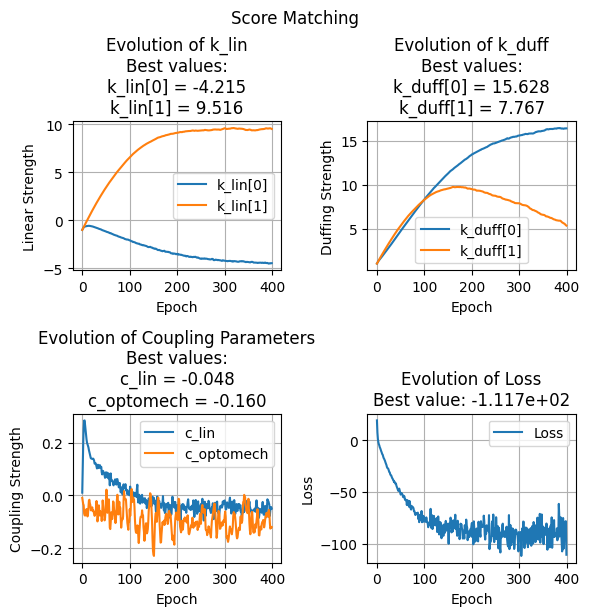

In [18]:
# For the first optimization
k_lin_best, k_duff_best, c_lin_best, c_optomech_best = plot_parameter_evolution(
    params_history=params_history_SM,
    loss_history=loss_history_SM,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="Score Matching"
)
args_best_sm = (k_lin_best, k_duff_best, c_lin_best, c_optomech_best)
flattened_args_best_sm, _ = flatten_util.ravel_pytree(args_best_sm)


### Contrastive Divergence 1

In [ ]:
# Define optimization parameters
learning_rate = learning_rate
n_epochs = n_epochs
batch_size = batch_size
loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
key, subkey = jr.split(key)
cd1_grad = lambda params, batch: -CD1_gradient(energy_fn, 
                                               batch, 
                                               params, 
                                               dt=0.001, 
                                               D=1, 
                                               key=key, 
                                               num_noise_samples=100)

params_history_cd1, loss_history_cd1 = run_optimization(loss_fn_per_batch = loss_fn_per_batch_SM, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples, 
                                                        gradient_fn_per_batch = cd1_grad, 
                                                        key=subkey,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01 -0.01]
Loss: 19.0748
---
Epoch 100
params:
[-0.59985164 -0.01716504  1.76303523  1.9768457   0.20920494 -0.18141603]
Loss: -11.7556
---
Epoch 200
params:
[-0.58318849  0.92147463  2.48355227  2.87194919  0.13253519 -0.15504945]
Loss: -24.2833
---
Epoch 300
params:
[-0.75926461  1.79854647  3.18855839  3.72344092  0.1058705  -0.13477545]
Loss: -34.0587
---
Epoch 400
params:
[-0.9518684   2.63956051  3.92609085  4.53060937  0.09469133 -0.08585847]
Loss: -42.6640
---
Epoch 500
params:
[-1.14947962  3.43330098  4.65617111  5.26748123  0.0758904  -0.19122957]
Loss: -53.0836
---
Epoch 600
params:
[-1.3287657   4.16601244  5.40140552  5.95436274  0.0658303  -0.14171625]
Loss: -55.7174
---
Epoch 700
params:
[-1.49389623  4.8234094   6.12832528  6.5780266   0.05480133 -0.2040136 ]
Loss: -63.4735
---
Epoch 800
params:
[-1.68400216  5.45081983  6.84193447  7.13057412  0.03379373 -0.19862928]
Loss: -67.0964
---
Epoch 900
params:
[-1.87645948  6.022008

Best loss: -1.1035e+02
Found at epoch: 2790


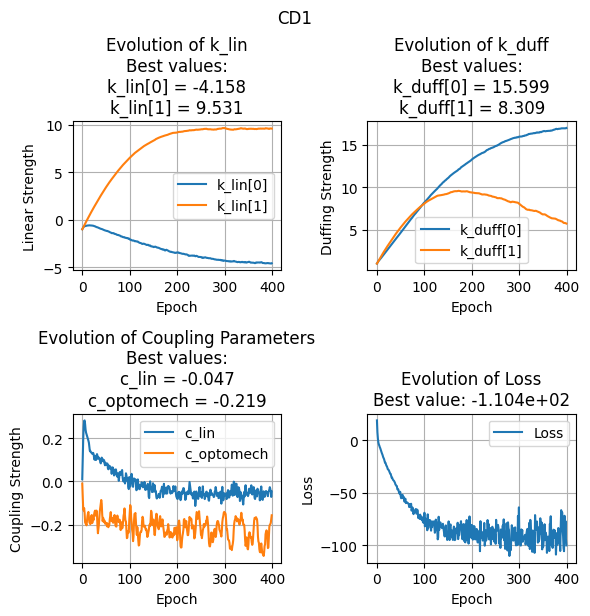

In [21]:
k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1 = plot_parameter_evolution(
    params_history=params_history_cd1,
    loss_history=loss_history_cd1,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="CD1"
)
args_best_cd1 = (k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1)
flattened_args_best_cd1, _ = flatten_util.ravel_pytree(args_best_cd1)


### MLE

In [27]:
# Define optimization parameters
learning_rate = .5
n_epochs = 100
batch_size = samples.shape[0]//2
key, subkey = jr.split(key)
loss_fn_per_batch_MLE = setup_MLE_loss_per_batch(energy_fn)
gradient_fn_per_batch_MLE = setup_MLE_gradient_per_batch(energy_fn, 
                                                     N_osc, 
                                                     gamma=1.0, 
                                                     k_b=1.0, 
                                                     T=1.0, 
                                                     t0=0.0, 
                                                     t1=10.0, 
                                                     N_samples=1000, 
                                                     dt0=0.01, 
                                                     initial_state=jnp.array([0.,0.]))

params_history_mle, loss_history_mle = run_optimization(loss_fn_per_batch = loss_fn_per_batch_MLE, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples,
                                                        gradient_fn_per_batch = gradient_fn_per_batch_MLE, 
                                                        key=key,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs, 
                                                        maximize=True)

Epoch 0
params:
[-0.5 -0.5  1.5  1.5  0.5  0.5]
Loss: 591.1292
---


Best loss: 6.8693e+02
Found at epoch: 96


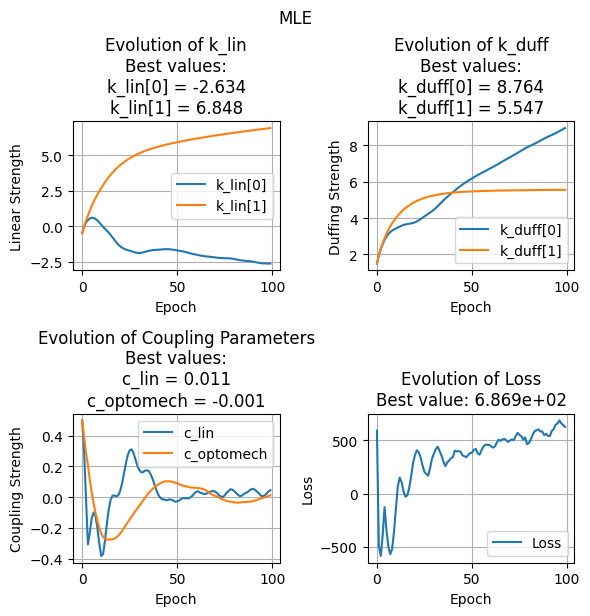

In [28]:
k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle = plot_parameter_evolution(
    params_history=params_history_mle,
    loss_history=loss_history_mle,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=1,
    title="MLE",
    maximize=True
)
args_best_mle = (k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle)
flattened_args_best_mle, _ = flatten_util.ravel_pytree(args_best_mle)

### Compare solutions

Initial Parameters probability distribution total (should be ≈ 1): 1.000000
Score Matching Best probability distribution total (should be ≈ 1): 1.000000
CD-1 Best probability distribution total (should be ≈ 1): 1.000000
MLE Best probability distribution total (should be ≈ 1): 1.000000


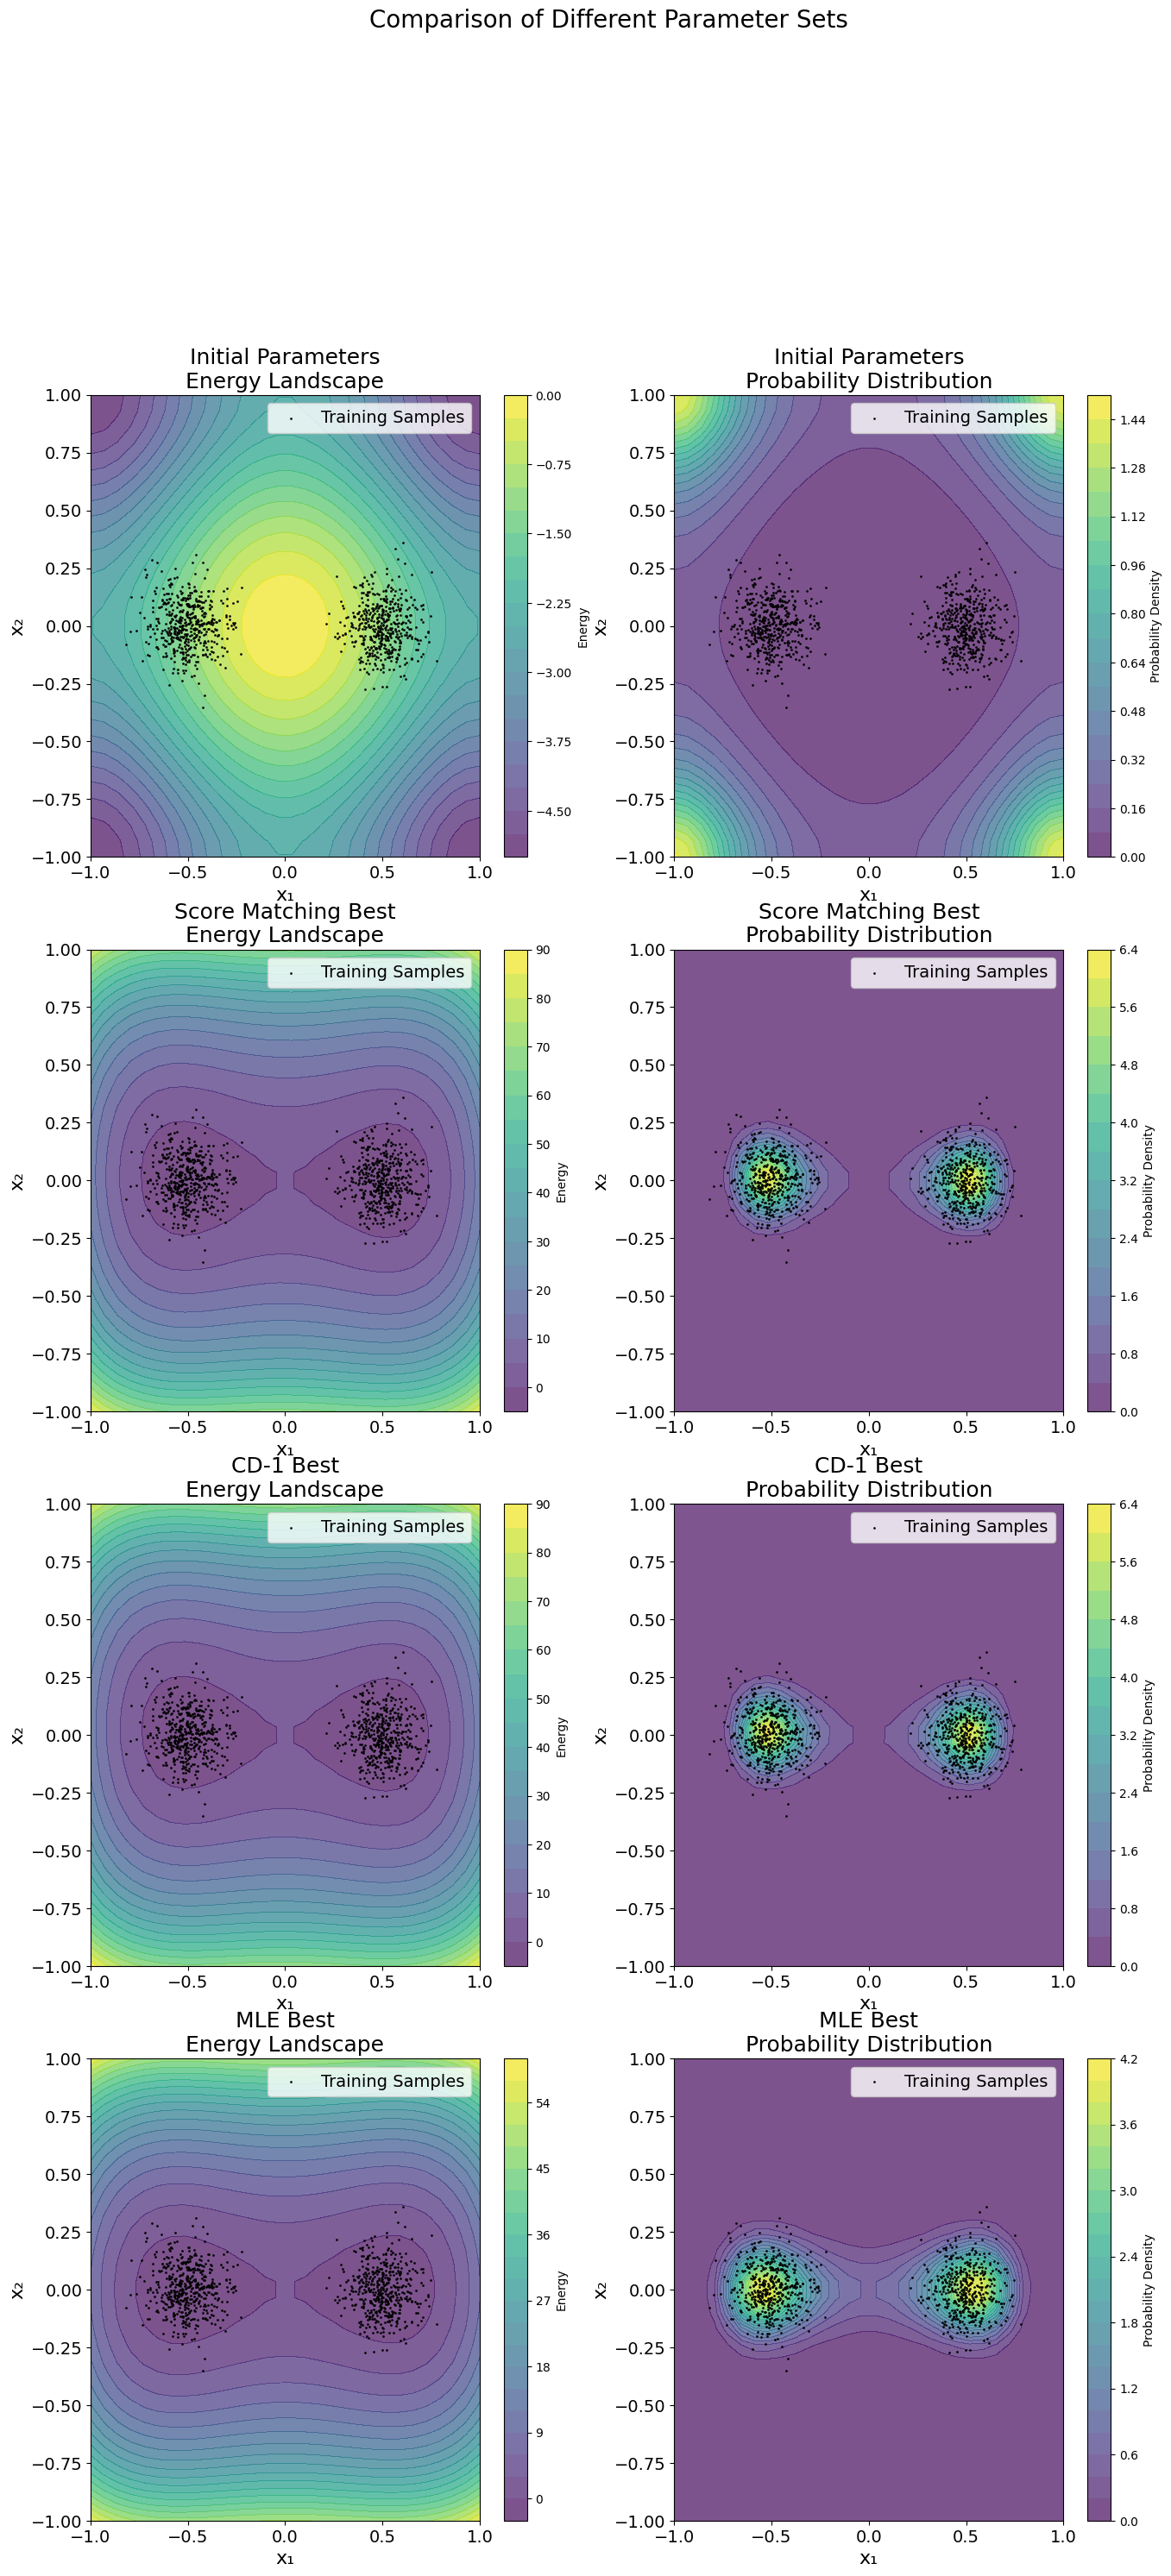

In [29]:
# Example usage:
param_list = [flattened_args_initial, flattened_args_best_sm, flattened_args_best_cd1, flattened_args_best_mle]
titles = ["Initial Parameters", "Score Matching Best", "CD-1 Best", "MLE Best"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    
    x2_range=(-1, 1),    
    n_points=30,        
    titles=titles,       
    figsize=None,    
    fontsize=16,
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets"  
)

### Run the SDE on one of the optimized energy landscape

In [25]:
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, flattened_args_best_sm, N_osc)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 10000)
dt0 = ts[1] - ts[0]
initial_state    = jnp.array([0.,0.])

solution = solve_SDE(drift_fn, diffusion_fn, initial_state, t0, t1, ts.shape[0], dt0)
sde_samples = solution.ys

Score Matching Best Energy  probability distribution total (should be ≈ 1): 1.000000


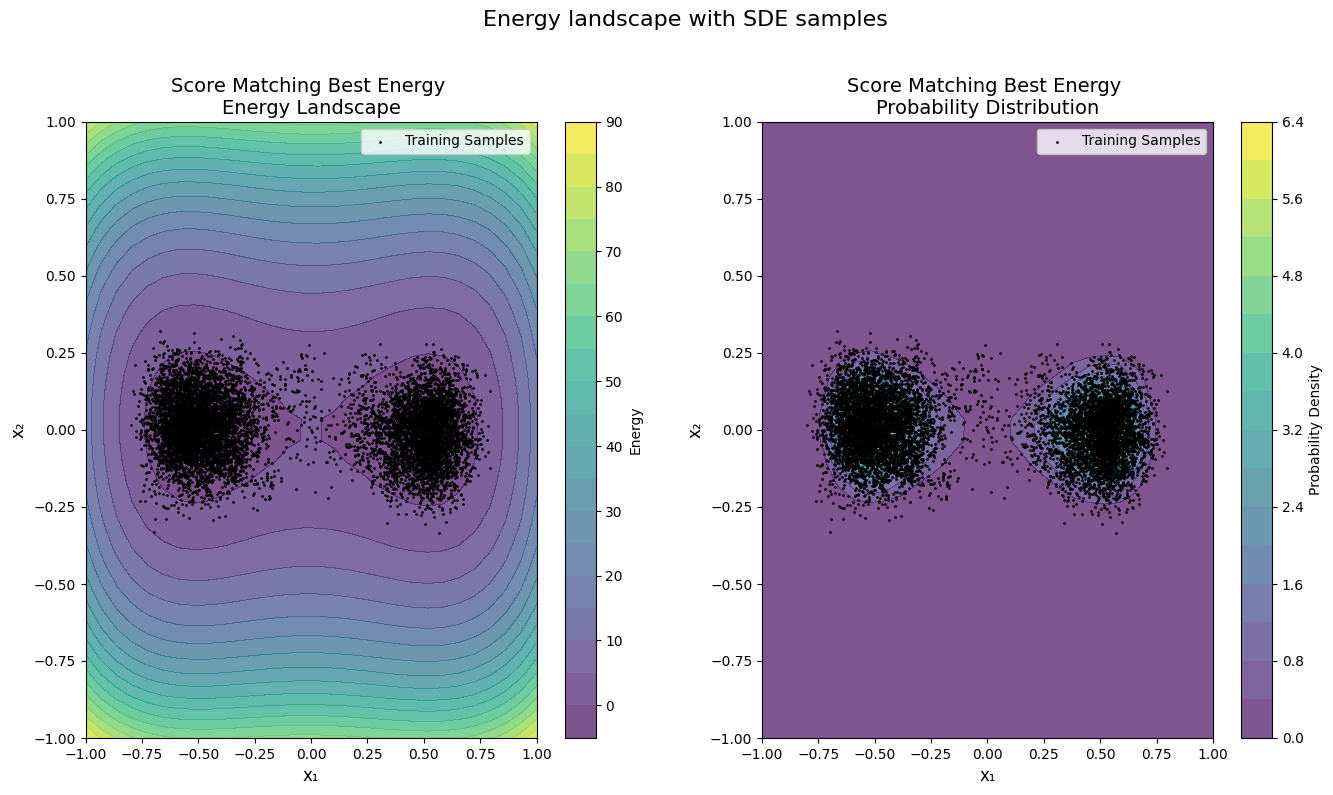

In [26]:
# Example usage:
param_list = [flattened_args_best_sm]
titles = ["Score Matching Best Energy "]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples,
    sample_stride=1,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Energy landscape with SDE samples"  # optional
)